In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("dataset9000.csv")

df.head()

,Database Fundamentals,Computer Architecture,Distributed Computing Systems,Cyber Security,Networking,Software Development,Programming Skills,Project Management,Computer Forensics Fundamentals,Technical Communication,AI ML,Software Engineering,Business Analysis,Communication skills,Data Science,Troubleshooting skills,Graphics Designing,Role
0,Professional,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
1,Professional,Poor,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
2,Professional,Beginner,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
3,Professional,Average,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator
4,Professional,Intermediate,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Database Administrator


In [7]:
df.shape

(9179, 18)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9179 entries, 0 to 9178
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Database Fundamentals            9179 non-null   object
 1   Computer Architecture            9179 non-null   object
 2   Distributed Computing Systems    9179 non-null   object
 3   Cyber Security                   9179 non-null   object
 4   Networking                       9179 non-null   object
 5   Software Development             9179 non-null   object
 6   Programming Skills               9179 non-null   object
 7   Project Management               9179 non-null   object
 8   Computer Forensics Fundamentals  9179 non-null   object
 9   Technical Communication          9179 non-null   object
 10  AI ML                            9179 non-null   object
 11  Software Engineering             9179 non-null   object
 12  Business Analysis                9

In [9]:
df.describe(include="all")

,Database Fundamentals,Computer Architecture,Distributed Computing Systems,Cyber Security,Networking,Software Development,Programming Skills,Project Management,Computer Forensics Fundamentals,Technical Communication,AI ML,Software Engineering,Business Analysis,Communication skills,Data Science,Troubleshooting skills,Graphics Designing,Role
count,9179,9179,9179,9179,9179,9179,9179,9179,9179,9179,9179,9179,9179,9179,9179,9179,9179,9179
unique,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,17
top,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Not Interested,Poor,Database Administrator
freq,1440,1440,1440,1440,1440,1440,1440,1440,1440,1440,1440,1440,1440,1440,1440,1440,1441,540


In [10]:
df.isnull().sum()

Database Fundamentals              0
Computer Architecture              0
Distributed Computing Systems      0
Cyber Security                     0
Networking                         0
Software Development               0
Programming Skills                 0
Project Management                 0
Computer Forensics Fundamentals    0
Technical Communication            0
AI ML                              0
Software Engineering               0
Business Analysis                  0
Communication skills               0
Data Science                       0
Troubleshooting skills             0
Graphics Designing                 0
Role                               0
dtype: int64

In [11]:
df.dropna(inplace=True)

In [12]:
df.duplicated().sum()

np.int64(1426)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.shape

(7753, 18)

In [15]:
df["Role"].value_counts()

Role
Helpdesk Engineer                  457
Database Administrator             456
Technical Writer                   456
Data Scientist                     456
Customer Service Executive         456
Business Analyst                   456
Software tester                    456
AI ML Specialist                   456
Information Security Specialist    456
Hardware Engineer                  456
Project Manager                    456
API Specialist                     456
Software Developer                 456
Networking Engineer                456
Cyber Security Specialist          456
Application Support Engineer       456
Graphics Designer                  456
Name: count, dtype: int64

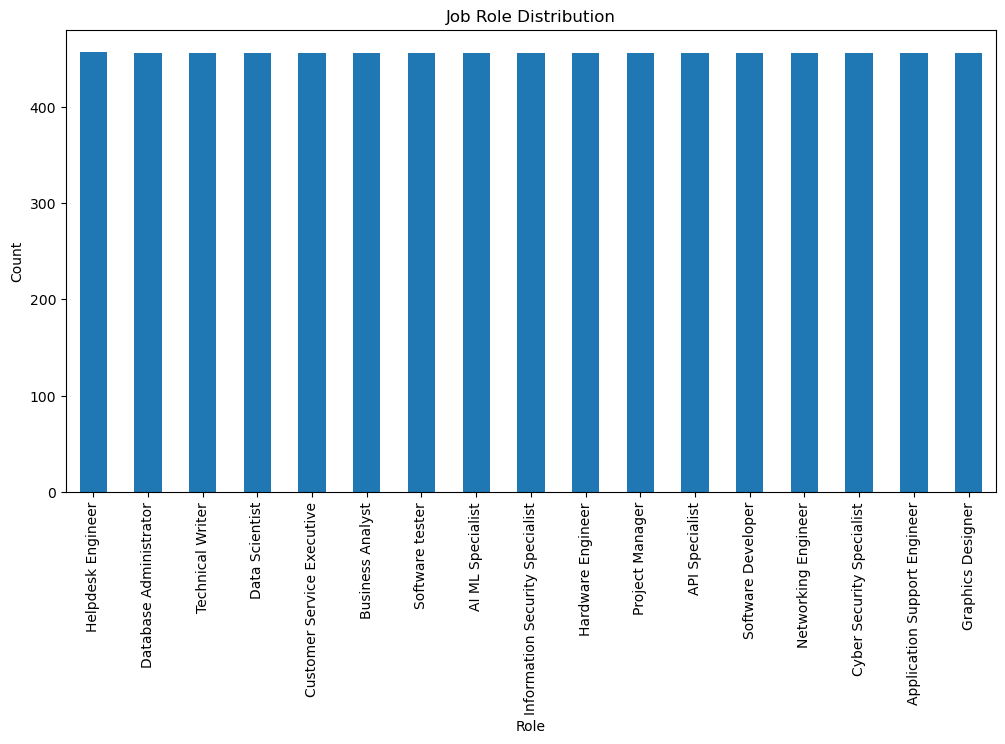

In [16]:
plt.figure(figsize=(12,6))

df["Role"].value_counts().plot(kind="bar")

plt.title("Job Role Distribution")

plt.xlabel("Role")

plt.ylabel("Count")

plt.xticks(rotation=90)

plt.show()

In [17]:
interest_map = {
    "Not Interested":0,
    "Beginner":1,
    "Intermediate":2,
    "Professional":3
}

feature_columns = df.columns[:-1]

for col in feature_columns:
    df[col] = df[col].map(interest_map)

In [18]:
from sklearn.preprocessing import LabelEncoder

role_encoder = LabelEncoder()

df["Role"] = role_encoder.fit_transform(df["Role"])

In [19]:
X = df.drop("Role", axis=1)

y = df["Role"]

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 1.0


In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       1.00      1.00      1.00        86
           2       1.00      1.00      1.00        95
           3       1.00      1.00      1.00        84
           4       1.00      1.00      1.00        93
           5       1.00      1.00      1.00       105
           6       1.00      1.00      1.00        98
           7       1.00      1.00      1.00        97
           8       1.00      1.00      1.00       100
           9       1.00      1.00      1.00        91
          10       1.00      1.00      1.00        81
          11       1.00      1.00      1.00        98
          12       1.00      1.00      1.00        84
          13       1.00      1.00      1.00        91
          14       1.00      1.00      1.00        91
          15       1.00      1.00      1.00        81
          16       1.00      1.00      1.00        89

    accuracy              

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[ 87,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [  0,  86,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [  0,   0,  95,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [  0,   0,   0,  84,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [  0,   0,   0,   0,  93,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [  0,   0,   0,   0,   0, 105,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,  98,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  97,   0,   0,   0,   0,   0,
          0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0, 100,   0,   0,   0,   0,
          0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  91,   0,   0,   0,
         

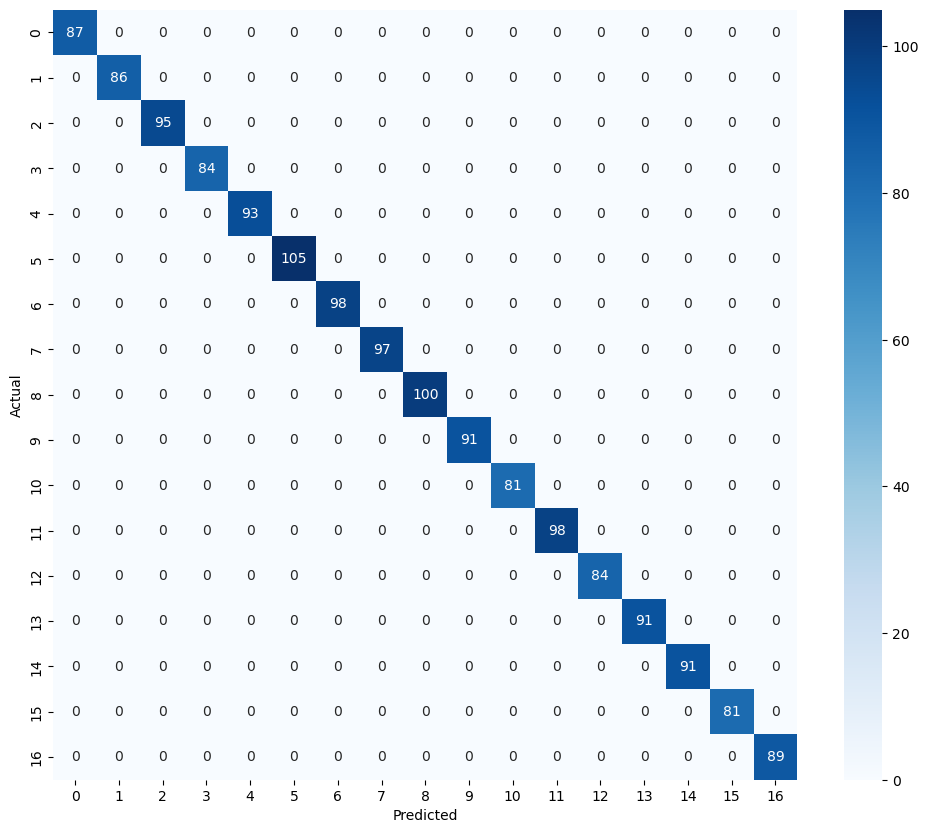

In [26]:
plt.figure(figsize=(12,10))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [27]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
15,Troubleshooting skills,0.062140
12,Business Analysis,0.061472
11,Software Engineering,0.061314
4,Networking,0.060414
10,AI ML,0.059877
1,Computer Architecture,0.059852
5,Software Development,0.059079
7,Project Management,0.059051
13,Communication skills,0.058933
6,Programming Skills,0.058849


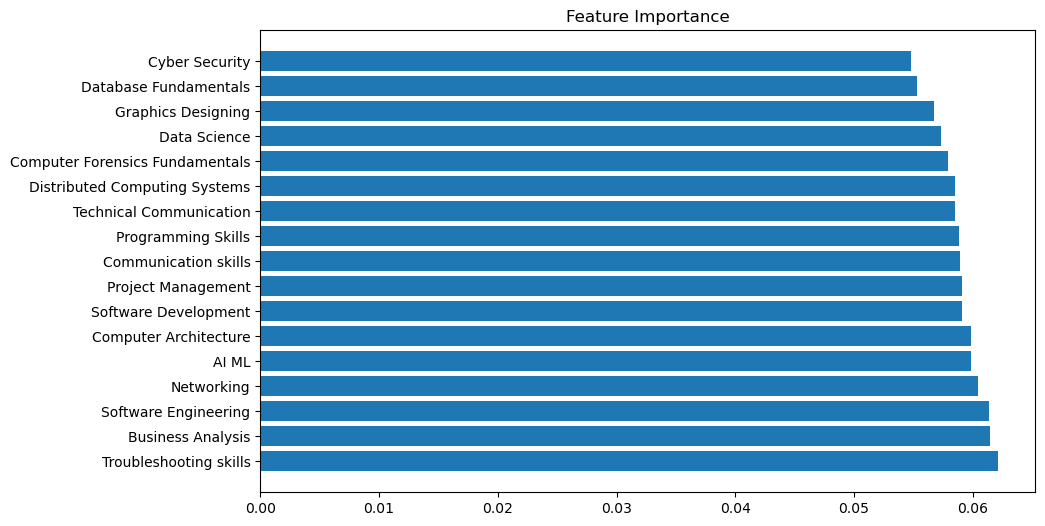

In [28]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.show()

In [29]:
import joblib

joblib.dump(model,"career_prediction_model.pkl")

['career_prediction_model.pkl']

In [30]:
joblib.dump(role_encoder,"role_encoder.pkl")

['role_encoder.pkl']

In [31]:
sample = [[
3,3,2,1,2,3,3,1,1,2,3,3,1,2,3,2,0
]]

prediction = model.predict(sample)

print("Predicted Role:")

print(role_encoder.inverse_transform(prediction))

Predicted Role:
['Software tester']


C:\Users\HP-PC\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
